# *Data Loading*

In [1]:
import pandas as pd

df = pd.read_csv("../data/Delivery_Logistics_reconstructed.csv")
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,...,weather_mult_recon,delivery_time_hours_recon,partner_mult_recon,delay_hours_recon,delayed_flag_recon,order_date_recon,order_ts_recon,delivery_ts_recon,expected_ts_recon,hour
0,250.99,amazon logistics,automobile parts,ev bike,standard,west,clear,235.6,48.07,no,...,1.0,9.332489,1.001906,-43.467511,0,21-10-2024,21-10-2024 13.00,2024-10-21 22:19:56.959673890,23-10-2024 17.48,13
1,250.99,amazon logistics,clothing,bike,express,central,stormy,81.8,45.51,yes,...,1.1,4.129935,1.001906,-3.870065,0,02-01-2024,02-01-2024 12.00,2024-01-02 16:07:47.764281093,02-01-2024 20.00,12
2,250.99,amazon logistics,clothing,van,same day,north,clear,282.9,31.33,yes,...,1.0,7.427398,1.001906,-18.972602,0,31-05-2024,31-05-2024 11.00,2024-05-31 18:25:38.631406710,01-06-2024 13.24,11
3,250.99,amazon logistics,cosmetics,ev bike,two day,central,hot,88.6,8.67,no,...,1.1,3.997011,1.001906,-44.002989,0,03-01-2024,03-01-2024 17.00,2024-01-03 20:59:49.240153885,05-01-2024 17.00,17
4,250.99,amazon logistics,cosmetics,ev van,two day,east,rainy,204.2,8.09,no,...,1.2,6.933351,1.001906,-45.866649,0,19-03-2024,19-03-2024 13.00,2024-03-19 19:56:00.063604276,21-03-2024 17.48,13


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   delivery_id                25000 non-null  float64
 1   delivery_partner           25000 non-null  object 
 2   package_type               25000 non-null  object 
 3   vehicle_type               25000 non-null  object 
 4   delivery_mode              25000 non-null  object 
 5   region                     25000 non-null  object 
 6   weather_condition          25000 non-null  object 
 7   distance_km                25000 non-null  float64
 8   package_weight_kg          25000 non-null  float64
 9   delayed                    25000 non-null  object 
 10  delivery_status            25000 non-null  object 
 11  delivery_rating            25000 non-null  int64  
 12  delivery_cost              25000 non-null  float64
 13  expected_time_hours_recon  25000 non-null  flo

,delivery_id,distance_km,package_weight_kg,delivery_rating,delivery_cost,expected_time_hours_recon,speed_kmph_recon,weather_mult_recon,delivery_time_hours_recon,partner_mult_recon,delay_hours_recon,delayed_flag_recon,hour
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.0000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,150.390436,25.145898,3.666000,864.944579,33.053344,39.9762,1.100310,5.360406,0.999994,-27.692938,0.029400,12.515400
std,7212.732314,86.409745,14.368663,1.149964,435.712593,17.592341,6.4653,0.064465,2.631007,0.003666,17.636803,0.168928,2.751564
min,250.990000,3.600000,0.670000,1.000000,95.667400,8.000000,30.0000,1.000000,0.640518,0.993437,-48.086207,0.000000,8.000000
25%,6250.750000,75.900000,12.680000,3.000000,490.800000,24.000000,35.0000,1.050000,3.180450,0.998812,-44.388864,0.000000,10.000000
50%,12500.500000,151.000000,25.145000,4.000000,867.535000,26.400000,40.0000,1.100000,5.227587,1.000945,-23.192956,0.000000,12.000000
75%,18750.250000,224.900000,37.660000,5.000000,1237.910000,48.000000,45.0000,1.150000,7.307020,1.002187,-14.075366,0.000000,15.000000
max,24750.010000,297.100000,49.520000,5.000000,1632.720600,52.800000,50.0000,1.200000,13.682192,1.005584,4.860295,1.000000,18.000000


In [3]:
df.isnull().sum()

delivery_id                  0
delivery_partner             0
package_type                 0
vehicle_type                 0
delivery_mode                0
region                       0
weather_condition            0
distance_km                  0
package_weight_kg            0
delayed                      0
delivery_status              0
delivery_rating              0
delivery_cost                0
expected_time_hours_recon    0
speed_kmph_recon             0
weather_mult_recon           0
delivery_time_hours_recon    0
partner_mult_recon           0
delay_hours_recon            0
delayed_flag_recon           0
order_date_recon             0
order_ts_recon               0
delivery_ts_recon            0
expected_ts_recon            0
hour                         0
dtype: int64

# *Data cleaning & preprocessing*

In [6]:
df["order_ts_recon"] = df["order_ts_recon"].str.replace(".", ":", regex=False)
df["expected_ts_recon"] = df["expected_ts_recon"].str.replace(".", ":", regex=False)

df["order_ts_recon"] = pd.to_datetime(df["order_ts_recon"], dayfirst=True)
df["expected_ts_recon"] = pd.to_datetime(df["expected_ts_recon"], dayfirst=True)

In [7]:
df["order_hour"] = df["order_ts_recon"].dt.hour
df["order_day"] = df["order_ts_recon"].dt.dayofweek
df["is_weekend"] = df["order_day"].isin([5,6]).astype(int)

In [9]:
df[["order_ts_recon","expected_ts_recon","order_hour","order_day","is_weekend"]].head()

,order_ts_recon,expected_ts_recon,order_hour,order_day,is_weekend
0,2024-10-21 13:00:00,2024-10-23 17:48:00,13,0,0
1,2024-01-02 12:00:00,2024-01-02 20:00:00,12,1,0
2,2024-05-31 11:00:00,2024-06-01 13:24:00,11,4,0
3,2024-01-03 17:00:00,2024-01-05 17:00:00,17,2,0
4,2024-03-19 13:00:00,2024-03-21 17:48:00,13,1,0


In [11]:
df.dtypes

delivery_id                         float64
delivery_partner                     object
package_type                         object
vehicle_type                         object
delivery_mode                        object
region                               object
weather_condition                    object
distance_km                         float64
package_weight_kg                   float64
delayed                              object
delivery_status                      object
delivery_rating                       int64
delivery_cost                       float64
expected_time_hours_recon           float64
speed_kmph_recon                      int64
weather_mult_recon                  float64
delivery_time_hours_recon           float64
partner_mult_recon                  float64
delay_hours_recon                   float64
delayed_flag_recon                    int64
order_date_recon                     object
order_ts_recon               datetime64[ns]
delivery_ts_recon               

<Axes: xlabel='order_hour', ylabel='count'>

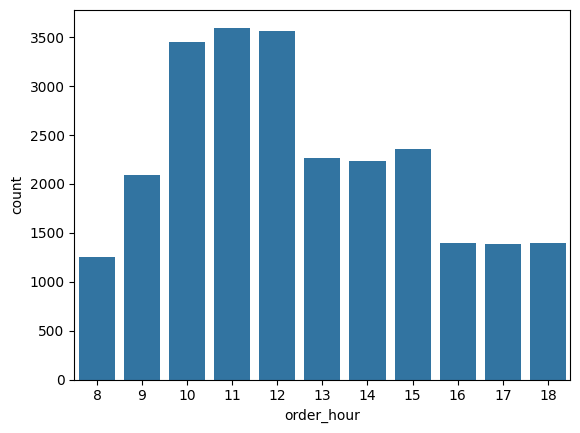

In [12]:
import seaborn as sns

sns.countplot(x="order_hour", data=df)

In [13]:
df["order_ts_recon"].isna().sum()

np.int64(0)

In [8]:
df.to_csv("../data/cleaned_dataset.csv", index=False)